## Script to find ROIs in muscle imaging data by PCA + NMF

Images too big for PCA, so will interatively cut sections off and run PCA + NMF
NMF works great to separate rois with large spatial overlap in both space and time. It doesn't produce binary ROIs though

Original dataset collected by Leandre Dubois (and Victor Stimpfling)



In [1]:
import cv2
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
from sklearn.decomposition import PCA


In [2]:
pupa_num = 1  # set pupa number (1, 2, etc.)
rec_num = 59  # set recording number

SAVE_NAME = 'TEST_section_legs_pupa1_rec1'

hz = 40

In [3]:
# get list of recordings sorted by number 
# (recoring# is not zero-padded in the folder names)
main_path = '/mnt/upramdya_data/MA/Development_project/LD'
pupa_path = os.path.join(main_path, f'pupa_{pupa_num}')
recording_list = os.listdir(pupa_path)

# remove any non-recording files
recording_list = [f for f in recording_list if 'recording' in f]

def extract_recording_number(filename):
    # 1. Remove the 'recording' prefix
    part_after_prefix = filename.split('recording', 1)[1]
    # 2. Extract the number up to the next underscore
    number_string = part_after_prefix.split('_', 1)[0]
    # 3. Convert the extracted string to an integer
    return int(number_string)

recording_list.sort(key=extract_recording_number)

In [ ]:
# get last recording folder (most active) and get average image to mask from
recording = recording_list[rec_num]
recording_path = os.path.join(pupa_path, recording)
print(recording)

h5_file = os.path.join(recording_path, 'video_raw.h5')

# get average image of first 100 frames
with h5py.File(h5_file, 'r') as f:
    # Access the data you need from the HDF5 file
    frames = f['frames'][:]
    ave = np.mean(frames[0:100], axis=0)


recording59_22032025_0411


In [16]:
def imshow_flip(image, ax=None, *args, **kwargs):
    if ax is None:
        plt.imshow(image, *args, **kwargs)
        ax = plt.gca()
    else:
        ax.imshow(image, *args, **kwargs)
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.axis('off')


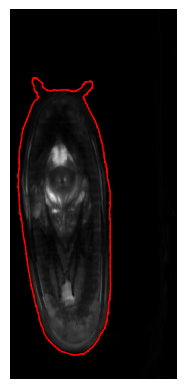

In [17]:
# mask to keep only the pupa

# threshold
thresh = 30
mask = (ave > thresh).astype(np.uint8) * 255

# find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# keep largest contour
contour = max(contours, key=cv2.contourArea)

# plot
plt.figure()
imshow_flip(ave, cmap='gray', vmin=30, vmax=130)
plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=1)
plt.show()

In [6]:
# get the bounding box of the contour (to only keep area for PCA)
x, y, w, h = cv2.boundingRect(contour)
print(f"Bounding box: x_0={x}, y_0={y}, width={w}, height={h}")

Bounding box: x_0=339, y_0=124, width=486, height=1443


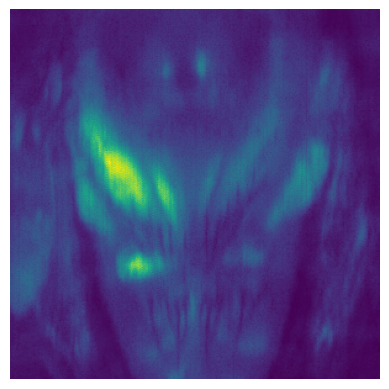

In [15]:
# SELECT ONE AREA FOR PCA TESTING

h1 = 300
w1 = 300
x1 = 435
y1 = 780

# h1 = 300
# w1 = 300
# x1 = 343 + 150
# y1 = 132 + 900

area1 = ave[y1:y1+h1, x1:x1+w1]

imshow_flip(area1)
plt.show()

In [19]:
# mask frames to only keep area for PCA
frames_masked = frames[:, y1:y1+h1, x1:x1+w1]

# Flatten frames for PCA
num_frames = frames_masked.shape[0]
frames_flat = frames_masked.reshape(num_frames, -1)
print(frames_flat.shape) # MAX for computer about 140'000 pixels

(4799, 90000)


In [20]:
# Initialize PCA and fit to the data
# try to load if it exists first (and save if not) - TAKES A LONG TIME!
pca_save_path = os.path.join(recording_path, f'pca_{SAVE_NAME}.pkl')
try:
    pca = pickle.load(open(pca_save_path, 'rb'))
    print('PCA loaded')
except:
    pca = PCA()
    pca.fit(frames_flat)
    pickle.dump(pca, open(pca_save_path, 'wb'))

PCA loaded


In [21]:
# Transform the data into principal components - get Scores for each PC (shape = n_pc x timepoints)
pca_scores = pca.transform(frames_flat)

# get principal components Loadings for each PC (shape = n_pc x n_pixels)
pca_loadings = pca.components_

# get explained variance ratio (shape = n_pc)
explained_variance = pca.explained_variance_ratio_

# get eigenvalues, scaling factor for each PC (shape = n_pc)
eigenvalues = pca.singular_values_

print(f"SHAPES: scores {pca_scores.shape}, loadings {pca_loadings.shape}, explained variance {explained_variance.shape}, eigenvalues {eigenvalues.shape}")

SHAPES: scores (4799, 4799), loadings (4799, 90000), explained variance (4799,), eigenvalues (4799,)


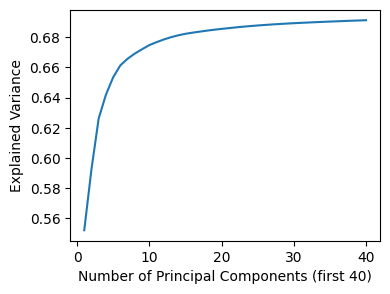

In [22]:
plt.figure(figsize=(4, 3))  
n = 40
plt.plot(np.array(range(n)) + 1, np.cumsum(explained_variance[0:n]))
plt.xlabel(f'Number of Principal Components (first {n})')
plt.ylabel('Explained Variance')

# save figure
save_path = os.path.join(recording_path, f'PCA_{SAVE_NAME}_explained_variance.png')
plt.savefig(save_path)

plt.show()



In [23]:
# Get the first few components loadings (for visualization)
num_components = 12
principal_components_n = pca_loadings[:num_components]  # Shape (num_components, n_pixels)

# Reconstruct components into 2D
reconstructed_components = []
for component in principal_components_n:
    component_2d = component.reshape(h1, w1)
    reconstructed_components.append(component_2d)

# Convert to NumPy array for easier handling (shape: num_components, width, height)
reconstructed_components = np.array(reconstructed_components)

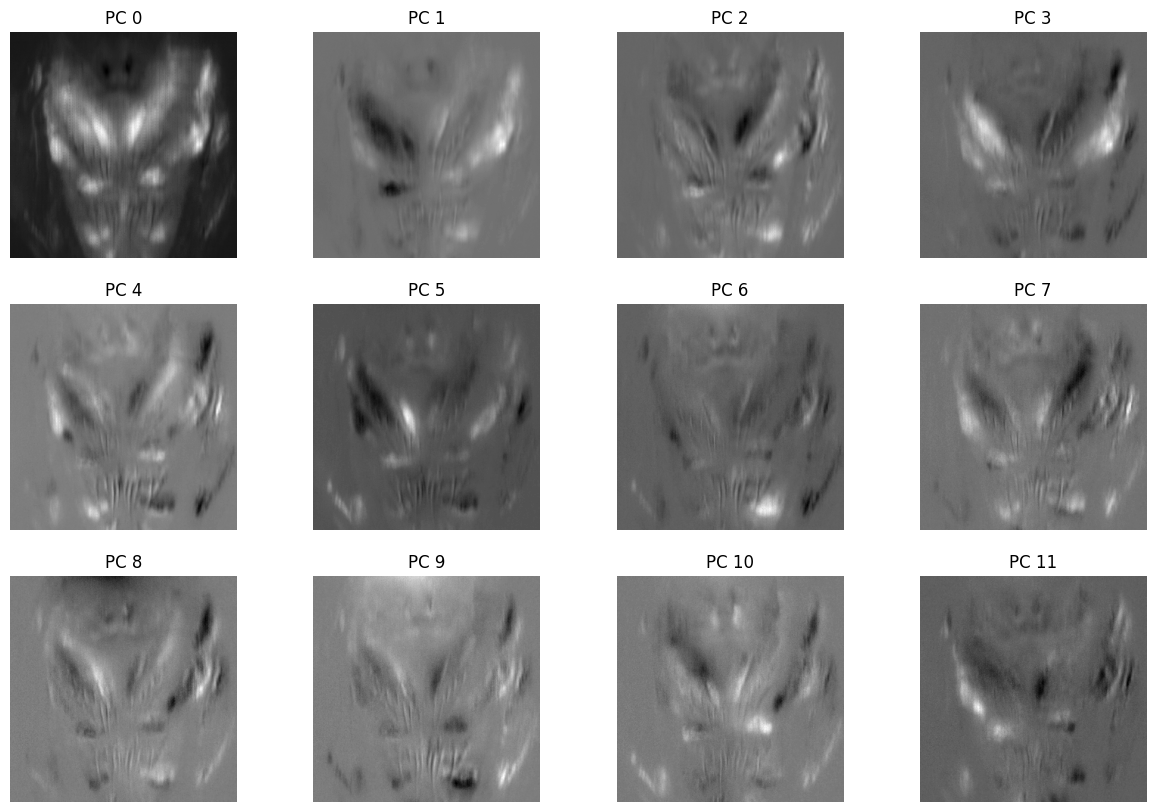

In [30]:
# plot top component loadings
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()
for i in range(np.min([num_components, len(axes)])):
    imshow_flip(reconstructed_components[i], axes[i], cmap='gray')
    axes[i].set_title(f'PC {i}')

# save figure
save_path = os.path.join(recording_path, f'first_9_PCs_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

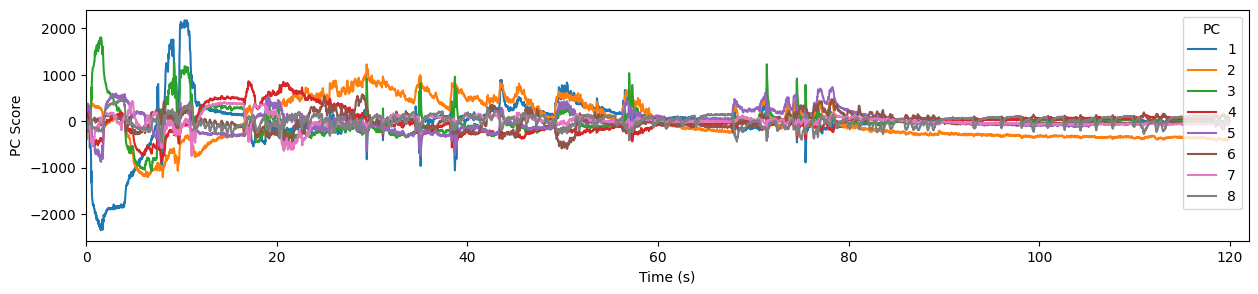

In [25]:
# plot scores for first few components in time
t = np.arange(pca_scores.shape[0])/hz
plt.figure(figsize=(15, 3))

plt.plot(t, pca_scores[:,1:9])
plt.legend(range(1, 9), title='PC', loc='upper right')
    
plt.xlabel('Time (s)')
plt.ylabel('PC Score')
plt.xlim(0, max(t)+2)

# save figure
save_path = os.path.join(recording_path, f'first_9_PCs_in_time_TEST_section.png')
plt.savefig(save_path)

plt.show()

(6.0, 20.0)

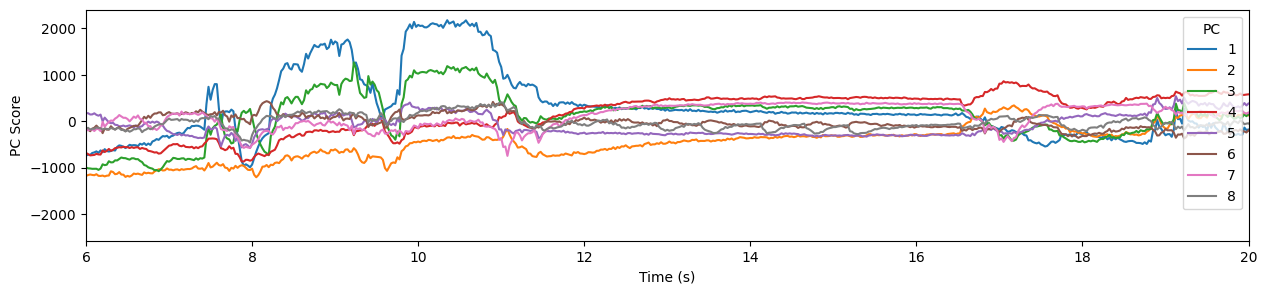

In [26]:
t = np.arange(pca_scores.shape[0])/hz
plt.figure(figsize=(15, 3))

plt.plot(t, pca_scores[:,1:9])
plt.legend(range(1, 9), title='PC', loc='upper right')
    
plt.xlabel('Time (s)')
plt.ylabel('PC Score')
plt.xlim([6,20])

## TRY NMF TO SEPARATE OVERLAPPING, NON-GAUSSIAN MUSCLES


In [27]:
# masked frames and reshape (pixels x time)
T, X, Y = frames_masked.shape
frames_flat = frames_masked.reshape(T, X * Y).T  # shape

In [28]:
from sklearn.decomposition import NMF

K = 20

nmf = NMF(n_components=K, init='nndsvda', max_iter=2000)
W = nmf.fit_transform(frames_flat)  # spatial
H = nmf.components_          # temporal


In [29]:
# reshape spatial maos to original shape
W_2 = W.T.reshape(K, Y, X)
print(W_2.shape)

(20, 300, 300)


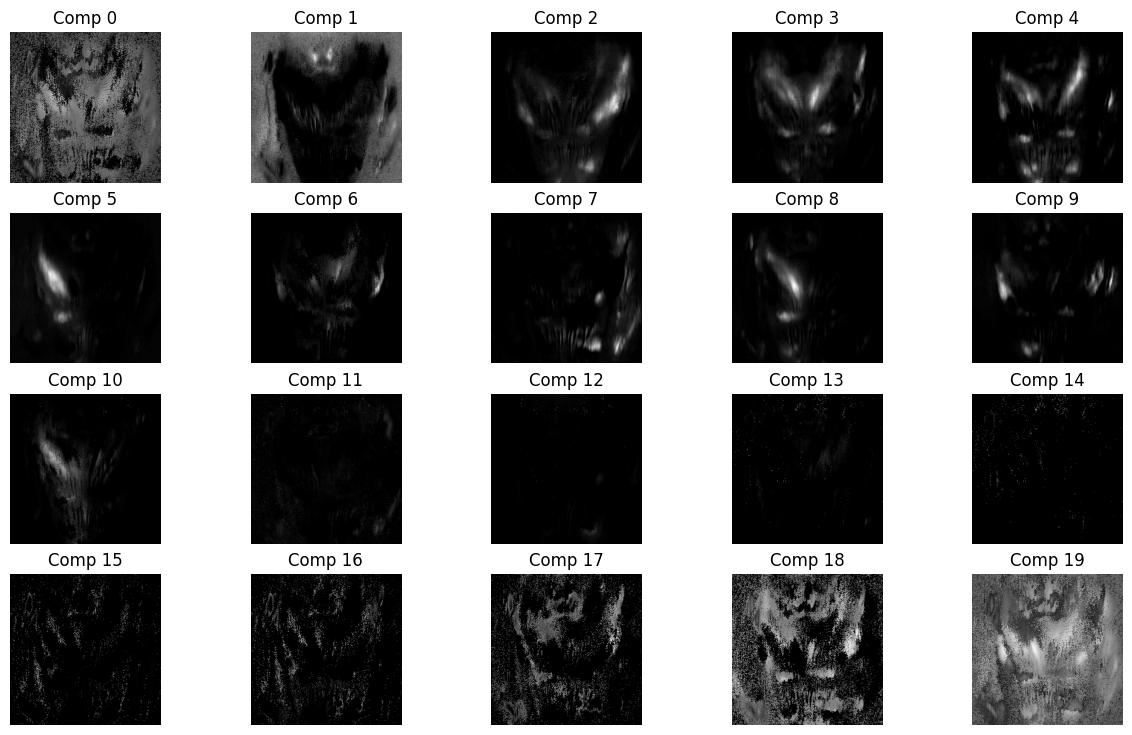

In [31]:
# plot top components
num_components = K
fig, axes = plt.subplots(4, 5, figsize=(15, 9))
axes = axes.flatten()
for i in range(min(num_components, len(axes))):
    imshow_flip(W_2[i], axes[i], cmap='gray')
    axes[i].set_title(f'Comp {i}')
    axes[i].axis('off')

# save figure
save_path = os.path.join(recording_path, f'MNF_spatial_comp_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

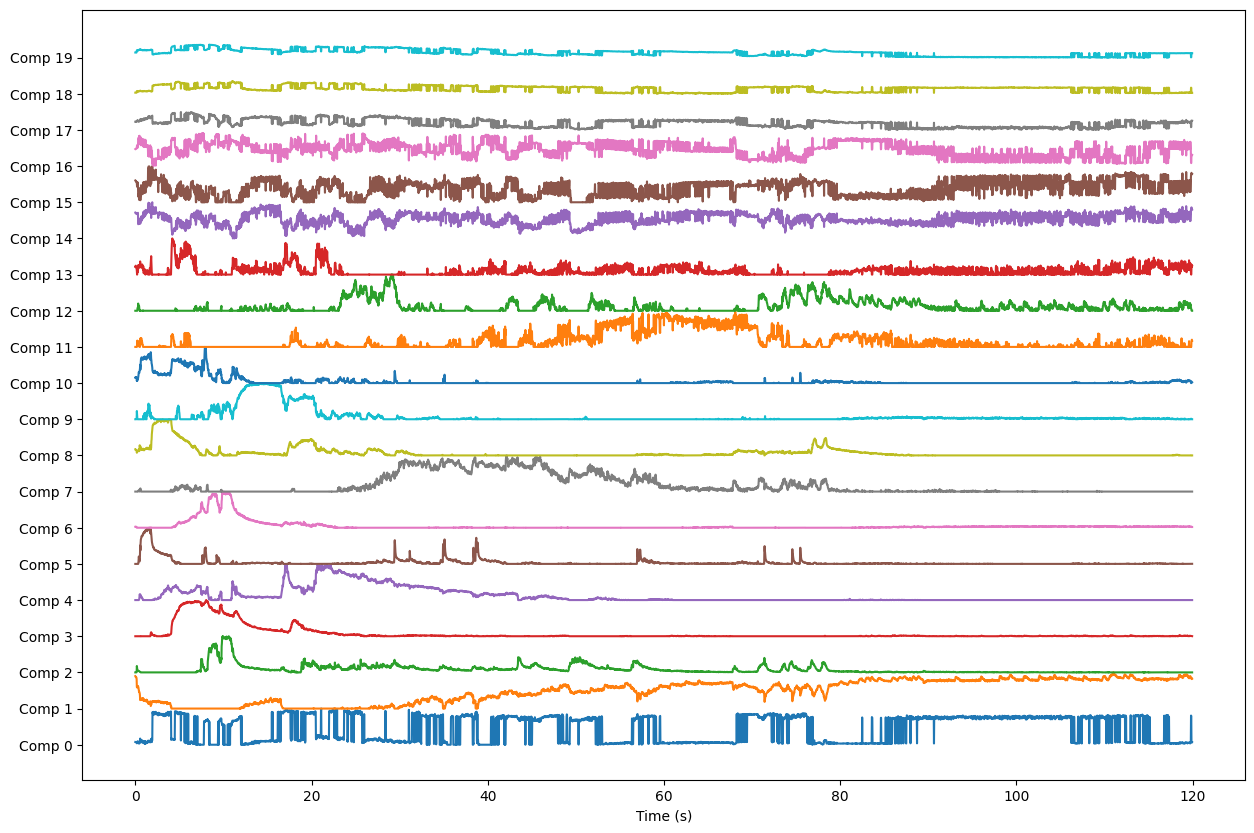

In [32]:
# plot all components in time above each other
t = np.arange(H.shape[1])/hz
plt.figure(figsize=(15, 10))
for c in range(H.shape[0]):
    H_temp = (H[c] - np.min(H[c])) / np.max(H[c])
    plt.plot(t, H_temp + c*1)  # offset each component for visibility
plt.xlabel('Time (s)')
plt.yticks(range(H.shape[0]), [f'Comp {i}' for i in range(H.shape[0])])

save_path = os.path.join(recording_path, f'MNF_time_comp_{SAVE_NAME}.png')
plt.savefig(save_path)

#plt.xlim([60,80])
#plt.ylim([-1, 25])

plt.show()

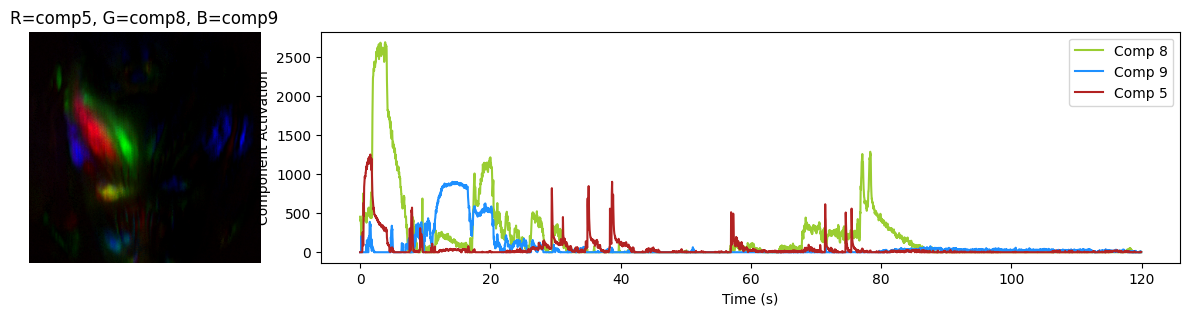

In [42]:
# overlay 3 components in RGB
comp_indices = [5, 8, 9]  # indices of components to use

rgb_image = np.zeros((h1, w1, 3), dtype=np.float32)
# #add area1 to rgb as white background (add to all 3 channels)
# norm = (area1 - area1.min()) / (area1.max() - area1.min())
# rgb_image += norm[..., None]
for i, comp_idx in enumerate(comp_indices):
    comp = W_2[comp_idx]
    # Normalize component to [0, 1]
    comp_norm = (comp - np.min(comp)) / (np.max(comp) - np.min(comp))
    rgb_image[:, :, i] += comp_norm
    # clip to max 1
rgb_image = np.clip(rgb_image, 0, 1)

plt.figure(figsize=(15,3))
plt.subplot(1,4,1)
imshow_flip(rgb_image)
plt.title(f'R=comp{comp_indices[0]}, G=comp{comp_indices[1]}, B=comp{comp_indices[2]}')

plt.subplot2grid((1, 4), (0, 1), colspan=3)
plt.plot(t, H[comp_indices[1]], label=f'Comp {comp_indices[1]}', color='yellowgreen')
plt.plot(t, H[comp_indices[2]], label=f'Comp {comp_indices[2]}', color='dodgerblue')
plt.plot(t, H[comp_indices[0]], label=f'Comp {comp_indices[0]}', color='firebrick')
plt.xlabel('Time (s)')
plt.ylabel('Component Activation')
plt.legend()
#plt.xlim([0, 10])

plt.show()

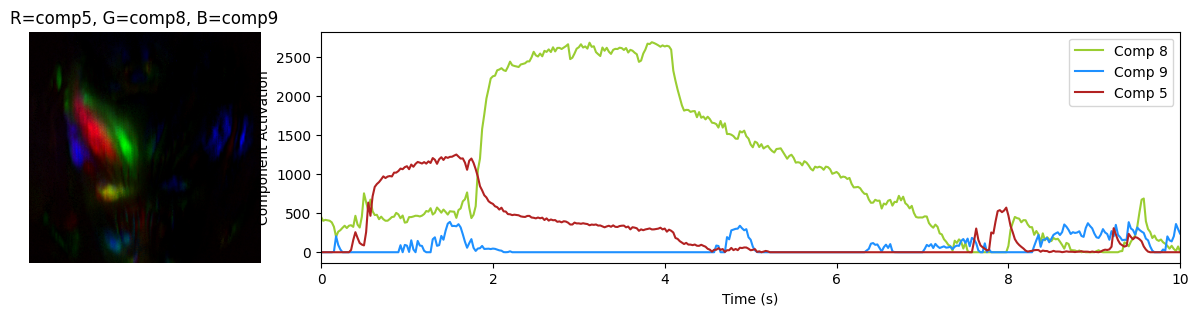

In [39]:
# overlay 3 components in RGB
comp_indices = [5, 8, 9]  # indices of components to use

rgb_image = np.zeros((h1, w1, 3), dtype=np.float32)
for i, comp_idx in enumerate(comp_indices):
    comp = W_2[comp_idx]
    # Normalize component to [0, 1]
    comp_norm = (comp - np.min(comp)) / (np.max(comp) - np.min(comp))
    rgb_image[:, :, i] += comp_norm
    # clip to max 1
rgb_image = np.clip(rgb_image, 0, 1)

plt.figure(figsize=(15,3))
plt.subplot(1,4,1)
imshow_flip(rgb_image)
plt.title(f'R=comp{comp_indices[0]}, G=comp{comp_indices[1]}, B=comp{comp_indices[2]}')

plt.subplot2grid((1, 4), (0, 1), colspan=3)
plt.plot(t, H[comp_indices[1]], label=f'Comp {comp_indices[1]}', color='yellowgreen')
plt.plot(t, H[comp_indices[2]], label=f'Comp {comp_indices[2]}', color='dodgerblue')
plt.plot(t, H[comp_indices[0]], label=f'Comp {comp_indices[0]}', color='firebrick')
plt.xlabel('Time (s)')
plt.ylabel('Component Activation')
plt.legend()
plt.xlim([0, 10])

plt.show()